# Notebook 04 — Discretização das Variáveis

**Projeto:** Mineração de Dados em Saúde · PNS 2019
**Estudo:** Artrite e Reumatismo em Idosos Brasileiros
**Pesquisador:** Pedro Dias Soares
**Orientador:** Prof. Dr. Luis Enrique Zárate — PUC Minas (LICAP)

---

## Por que esta etapa existe (e por que num notebook próprio)

A discretização é a **etapa 7 do KDD** (slide *Introdução12 — Preparação dos dados*) e foi
isolada num notebook dedicado para deixar **cada corte auditável e rastreável**. O slide a
define como "transformar atributos quantitativos em qualitativos com número finito de
intervalos", com três ganhos: (1) algoritmos como Árvore de Decisão/Naïve Bayes operam melhor
sobre categóricos; (2) **redução de dimensionalidade**; (3) **suavização de outliers** (valores
extremos caem dentro de um nível) — argumento explícito no artigo de *Hipertensão (CBIS'24)*.

## Como os artigos do orientador discretizam (padrão seguido aqui)

Verifiquei 6 artigos do LICAP sobre a PNS (AVC, Depressão, Artrite+Depressão, TOC, DPOC,
Hipertensão). O padrão é **uniforme**:

- Discretização **não-supervisionada, univariada, por faixas de domínio** — cortes vindos de
  fontes oficiais (OMS, NIAAA, IBGE, Ministério da Saúde, Guia de Atividade Física BR 2021),
  **não** dos dados.
- "Risco crescente = nível maior" (categórico **ordinal**), para favorecer interpretabilidade.
- **Entropia + correlação** aparecem, mas para **selecionar/remover atributos** — *nunca* para
  definir os cortes. Este notebook respeita essa divisão.

## Pipeline (Opção A — fonte única de discretização)

Os notebooks **03** (artrite pura) e **03b** (artrite + comorbidades) entregam as variáveis
contínuas ainda **numéricas** (a antiga "Etapa 10" de categorização foi migrada para cá). Assim
não há discretização duplicada — a mesma lógica que isolou o tratamento de outliers.

## Este notebook processa OS DOIS desenhos

- **Parte A (passo a passo):** roda um desenho à escolha (`DESENHO`), célula a célula, com os
  gráficos de diagnóstico — para você inspecionar e calibrar os cortes.
- **Parte B (lote):** a Seção 12 reúne a lógica numa função e executa **ambos** os desenhos de
  uma vez, gravando os dois `dataset_discretizado.csv` + os dois `relatorio_discretizacao.json`.

| # | Etapa | O que faz |
|---|-------|-----------|
| 1 | Configuração | Imports, caminhos por desenho, paleta, helpers |
| 2 | Carregamento | Lê o dataset pré-processado do desenho ativo |
| 3 | Mapa de discretização | Faixas **+ fonte** (domínio) e plano cartesiano dos escores |
| 4 | Inventário | O que ainda é contínuo × o que já é categórico |
| 5 | Diagnóstico ANTES | Histogramas por intervalo (slide) |
| 6 | Discretização por domínio | Binning não-supervisionado com faixas oficiais |
| 7 | Plano cartesiano alimentar | `Escore_Inflamatorio` × `Escore_Saudavel` → 4 quadrantes (mediana) |
| 8 | Perda de informação | Prevalência da classe por faixa (Figuras dos artigos) |
| 9 | Seleção entropia+correlação | Poda/sinalização de atributos (padrão dos artigos) |
| 10 | Codificação ordinal | `_cat` como inteiro 0..k e remoção das contínuas originais |
| 11 | Exportação | CSV + JSON do desenho ativo |
| 12 | **Lote** | Roda os DOIS desenhos de uma vez |

> Convenção de cor: <span style="color:#C0392B">**vermelho = Com Artrite**</span>,
> <span style="color:#27AE60">**verde = Saudável**</span>.

## 1 · Configuração do ambiente

Mesma base do NB03 (paleta, helpers, `RANDOM_STATE=42`). O dicionário `CONFIG_DESENHOS`
centraliza, para cada desenho, **de onde ler** (saída do 03/03b) e **onde gravar**. A variável
`DESENHO` escolhe qual desenho a *Parte A* percorre passo a passo. A *Parte B* (Seção 12) usa
todos os desenhos do dicionário.

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for _cat in (FutureWarning, DeprecationWarning, UserWarning):  # silencia avisos de depreciação (pandas/seaborn)
    warnings.filterwarnings('ignore', category=_cat)

# ── Mapa dos dois desenhos: entrada (saída do NB03/03b) e saída (deste NB) ──
# ── Configuração central (config.toml — fonte única; substitui constantes duplicadas) ──
try:
    import tomllib                       # Python 3.11+ (stdlib)
except ModuleNotFoundError:
    import tomli as tomllib              # Python 3.10: pip install tomli
with open('../config.toml', 'rb') as _f:
    CFG = tomllib.load(_f)
CONFIG_DESENHOS = CFG['desenhos']   # de config.toml (entrada=pré-proc, saída=disc)

# Desenho percorrido na PARTE A (passo a passo). A PARTE B roda os dois.
DESENHO = 'puro'

RANDOM_STATE = CFG['pipeline']['random_state']
COR_ARTRITE  = CFG['cores']['artrite']    # vermelho (config.toml)
COR_SAUDAVEL = CFG['cores']['saudavel']   # verde (config.toml)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

def preparar_dirs(saida):
    figs, tabs = saida + 'figuras/', saida + 'tabelas/'
    for p in (saida, figs, tabs):
        os.makedirs(p, exist_ok=True)
    return figs, tabs

def salvar_fig(figs, nome):
    plt.savefig(figs + nome, dpi=150, bbox_inches='tight'); print(f'  ✅ Figura → {figs+nome}')

def salvar_tab(tabs, df, nome):
    df.to_csv(tabs + nome, encoding='utf-8-sig');           print(f'  ✅ Tabela → {tabs+nome}')

def dist_serializavel(d):
    """Coage chaves/valores de uma distribuição (value_counts) p/ tipos nativos do JSON."""
    out = {}
    for k, v in d.items():
        out['NaN' if pd.isna(k) else int(k)] = int(v)
    return out

def discretizar_plano_alimentar(serie_infl, serie_saud):
    """Plano cartesiano dos padrões alimentares (Ribeiro & Zárate, 2019, ESWA).
    Combina 2 escores em 4 quadrantes por corte na MEDIANA de cada eixo.
    Código = infl_alto*2 + (1 - saud_alto)  → o eixo inflamatório domina o risco.
    0=Protetor · 1=Pobre · 2=Misto · 3=Pró-inflamatório.
    3.4 (vazamento): a MEDIANA é o ÚNICO corte data-driven do NB04 (os demais são faixas de
    domínio fixas: OMS/idade/Guia AF/NIAAA, sem vazamento). É alvo-cega, mas ajustada na base
    inteira; no NB06 deve ser REAJUSTADA in-fold (mediana só do treino) dentro da CV."""
    infl = pd.to_numeric(serie_infl, errors='coerce')
    saud = pd.to_numeric(serie_saud, errors='coerce')
    infl_alto = (infl > infl.median()).astype(int)
    saud_alto = (saud > saud.median()).astype(int)
    return (infl_alto * 2 + (1 - saud_alto)).astype('Int64')

# Dirs do desenho ATIVO (Parte A)
cfg = CONFIG_DESENHOS[DESENHO]
DIR_RESULTADOS = cfg['saida']
DIR_FIGURAS, DIR_TABELAS = preparar_dirs(DIR_RESULTADOS)

print(f'✅ Ambiente configurado. Desenho ativo (Parte A) = {DESENHO!r} — {cfg["rotulo"]}')
print(f'   Entrada : {cfg["entrada"]}')
print(f'   Saída   : {DIR_RESULTADOS}')

✅ Ambiente configurado. Desenho ativo (Parte A) = 'puro' — Desenho 1 — Artrite pura
   Entrada : ../data/results/preprocessing/dataset_preprocessado.csv
   Saída   : ../data/results/discretizacao/


## 2 · Carregamento do dataset pré-processado

Lê o `dataset_preprocessado.csv` do desenho ativo. A coluna `Label` (0=Saudável, 1=Com Artrite)
é separada e **nunca** é discretizada — só é usada nas Etapas 8/9 (perda de informação e seleção
supervisionada). O `assert` protege contra rodar antes do NB03 correspondente.

In [2]:
caminho_in = cfg['entrada']
assert os.path.exists(caminho_in), f'Arquivo não encontrado: {caminho_in}. Rode o NB03/03b antes.'
df = pd.read_csv(caminho_in)
print(f'  ✅ Carregado: {df.shape[0]:,} registros × {df.shape[1]} colunas')

assert 'Label' in df.columns, "Coluna 'Label' não encontrada — confira a saída do NB03."
y = df['Label'].astype(int)
X = df.drop(columns=['Label']).copy()
print(f'  Distribuição do alvo: {dict(y.value_counts())}')
X.head()

  ✅ Carregado: 4,826 registros × 72 colunas
  Distribuição do alvo: {0: 4332, 1: 494}


,P00104,P00404,C008,P035,P00901,P015,P018,P01101,P02501,P02002,...,P02401_Integral,P02401_Os dois tipos,P02101_Diet/Light/Zero,P02101_Normal,P02102_Diet/Light/Zero,P02102_Normal,P00612_Sim,P00614_Sim,P00615_Sim,P00616_Sim
0,72.0,157.0,63.0,2.0,7.0,1.0,3.0,3.0,0.0,0.0,...,0,0,0,1,0,1,1,0,1,0
1,76.0,158.0,61.0,0.0,2.0,0.0,0.0,7.0,0.0,5.0,...,1,0,0,1,0,1,0,1,0,0
2,77.0,162.0,67.0,7.0,7.0,2.0,7.0,2.0,0.0,0.0,...,1,0,0,1,0,1,1,0,0,0
3,54.0,165.0,62.0,5.0,0.0,0.0,2.0,5.0,7.0,0.0,...,1,0,0,1,0,1,1,0,0,1
4,39.0,163.0,63.0,0.0,3.0,0.0,0.0,7.0,0.0,0.0,...,1,0,0,1,0,1,0,0,0,0


## 3 · Mapa de discretização (faixas + fonte de cada corte)

**Coração metodológico.** Todos os cortes ficam num único dicionário, cada um com sua **fonte
oficial** — o padrão "faixa + citação" dos artigos do orientador (IMC→OMS, atividade física→
Guia BR 2021). O mapa é **comum aos dois desenhos** (IMC, idade, atividade física e os escores
existem em ambos), por isso o NB04 atende os dois sem alteração de regras.

`right=False` ⇒ intervalos `[a, b)` (use quando o limite superior pertence à próxima faixa,
como na OMS do IMC). `FAIXAS_QUANTIS` é só para escores compostos que **não** têm norma externa.

In [3]:
# Faixas por DOMÍNIO (fonte oficial). Cortes no formato pd.cut.
# Faixas de domínio vindas do config.toml (cada corte com a sua fonte oficial).
FAIXAS = {f['var']: {'bins': f['bins'], 'labels': f['labels'], 'right': f['right'], 'fonte': f['fonte']}
          for f in CFG['discretizacao']['faixa']}

# Faixas por QUANTIS (equal-frequency) — reservado p/ escores sem referência externa.
# Os escores alimentares NÃO entram aqui: viram um plano cartesiano (ver abaixo).
FAIXAS_QUANTIS = {}

# Plano cartesiano dos padrões alimentares (Ribeiro & Zárate, 2019, ESWA):
# Escore_Inflamatorio (eixo X) × Escore_Saudavel (eixo Y); corte pela MEDIANA em
# cada eixo → 4 quadrantes numa única feature ordinal. O eixo inflamatório domina
# o risco (peso 2). Substitui os quartis dos 2 escores e aposenta a Razao_Inf_Saud.
PLANO_ALIMENTAR = {
    'eixo_infl':'Escore_Inflamatorio', 'eixo_saud':'Escore_Saudavel',
    'nova':'Padrao_Alimentar_cat',
    'rotulos':{0:'Protetor', 1:'Pobre', 2:'Misto', 3:'Pró-inflamatório'},
    'remover_extra':['Razao_Inf_Saud'],
    'fonte':'Plano cartesiano de padrões alimentares (Ribeiro & Zárate, 2019, ESWA) — corte pela mediana',
}

# Contínuas REDUNDANTES após a fusão do NB03 — saem do dataset final:
#   peso/altura ⊂ IMC_cat ; os 9 itens de frequência ⊂ Padrao_Alimentar_cat.
COLUNAS_REDUNDANTES = (
    ['P00104', 'P00404']                                     # peso/altura ⊂ IMC
    + ['P01101', 'P02501', 'P02002', 'P02001']               # itens do Escore Inflamatório ⊂ plano
    + ['P018', 'P00901', 'P015', 'P023', 'P01601']           # itens do Escore Saudável ⊂ plano
)
print('  Faixas por domínio :', list(FAIXAS))
print('  Faixas por quantis :', list(FAIXAS_QUANTIS), '(escores → plano cartesiano)')
print('  Plano alimentar    :', PLANO_ALIMENTAR['nova'])

  Faixas por domínio : ['IMC', 'C008', 'P035', 'J012', 'P029', 'P006', 'P013', 'P02602', 'P02801', 'P03202']
  Faixas por quantis : [] (escores → plano cartesiano)
  Plano alimentar    : Padrao_Alimentar_cat


## 4 · Inventário das variáveis

Classifica as colunas em **discretizar** (numérica com faixa definida), **numérica não mapeada**
(decidir: criar faixa, mandar p/ quantis ou manter) e **já categórica** (dummies OHE 0/1 e
ordinais herdadas do NB03). Como os dois desenhos têm conjuntos de colunas diferentes (o Desenho 2
mantém as `Q*`), essa detecção automática é o que torna o NB04 robusto a ambos.

In [4]:
mapeadas = set(FAIXAS) | set(FAIXAS_QUANTIS)
n_unicos = X.nunique(dropna=True)
col_numerica = [c for c in X.columns
                if pd.api.types.is_numeric_dtype(X[c]) and n_unicos[c] > 2]
a_discretizar  = [c for c in col_numerica if c in mapeadas]
nao_mapeadas   = [c for c in col_numerica if c not in mapeadas]
ja_categoricas = [c for c in X.columns if c not in col_numerica]

inv = pd.DataFrame({'coluna':X.columns,
    'n_unicos':[int(n_unicos[c]) for c in X.columns],
    'grupo':['discretizar' if c in a_discretizar
             else 'numérica_não_mapeada' if c in nao_mapeadas
             else 'já_categórica' for c in X.columns]})
print(inv['grupo'].value_counts(), '\n')
print('  A discretizar      :', a_discretizar)
print('  Numéricas s/ faixa :', nao_mapeadas, '  ← decidir o que fazer')
salvar_tab(DIR_TABELAS, inv.set_index('coluna'), 'etapa4_inventario_variaveis.csv')
inv

grupo
já_categórica           41
numérica_não_mapeada    20
discretizar             10
Name: count, dtype: int64 

  A discretizar      : ['C008', 'P035', 'P02602', 'P006', 'P013', 'J012', 'P02801', 'P029', 'P03202', 'IMC']
  Numéricas s/ faixa : ['P00104', 'P00404', 'P00901', 'P015', 'P018', 'P01101', 'P02501', 'P02002', 'P02001', 'P023', 'P01601', 'VDF004', 'VDD004A', 'N001', 'N010', 'N011', 'G081', 'Q05901', 'Escore_Inflamatorio', 'Escore_Saudavel']   ← decidir o que fazer
  ✅ Tabela → ../data/results/discretizacao/tabelas/etapa4_inventario_variaveis.csv


,coluna,n_unicos,grupo
0,P00104,86,numérica_não_mapeada
1,P00404,64,numérica_não_mapeada
2,C008,43,discretizar
3,P035,8,discretizar
4,P00901,8,numérica_não_mapeada
...,...,...,...
66,P02102_Normal,2,já_categórica
67,P00612_Sim,2,já_categórica
68,P00614_Sim,2,já_categórica
69,P00615_Sim,2,já_categórica


## 5 · Diagnóstico ANTES da discretização

O slide *Introdução11/12* mostra que o padrão só aparece **no histograma por intervalos**. Antes
de cortar, observamos cada contínua com os cortes marcados — o "será que os intervalos são os
mais adequados?" do slide.

  ✅ Figura → ../data/results/discretizacao/figuras/etapa5_hist_antes.png


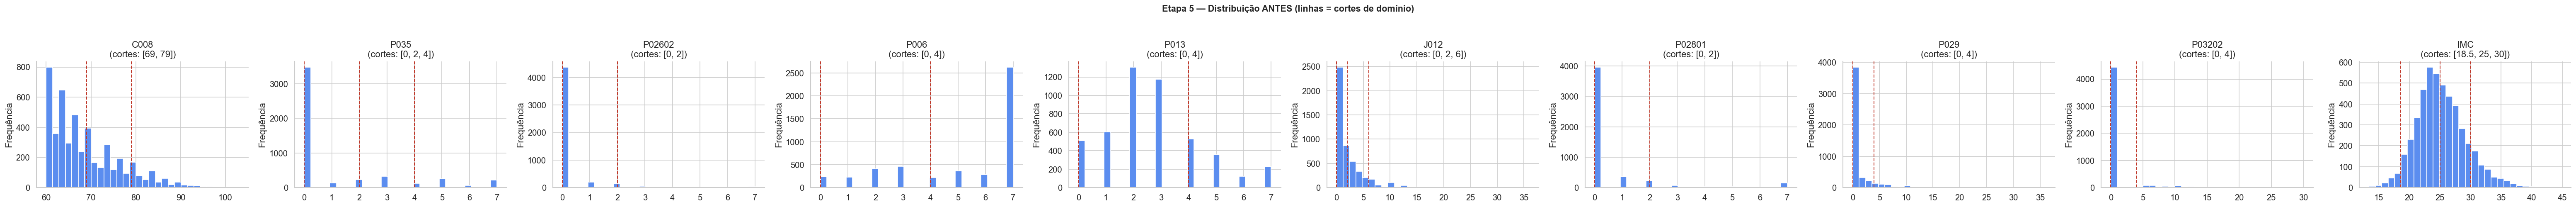

In [5]:
alvo_plot = [c for c in a_discretizar if c in FAIXAS and c in X.columns]  # só faixas de domínio têm cortes p/ desenhar
if alvo_plot:
    fig, axes = plt.subplots(1, len(alvo_plot), figsize=(5.2*len(alvo_plot), 4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, alvo_plot):
        serie = pd.to_numeric(X[col], errors='coerce').dropna()
        ax.hist(serie, bins=30, color='#5B8DEF', edgecolor='white')
        for corte in FAIXAS[col]['bins'][1:-1]:
            ax.axvline(corte, color=COR_ARTRITE, ls='--', lw=1.2)
        ax.set_title(f'{col}\n(cortes: {FAIXAS[col]["bins"][1:-1]})'); ax.set_ylabel('Frequência')
    fig.suptitle('Etapa 5 — Distribuição ANTES (linhas = cortes de domínio)', y=1.04,
                 fontsize=13, weight='bold')
    plt.tight_layout(); salvar_fig(DIR_FIGURAS, 'etapa5_hist_antes.png'); plt.show()
else:
    print('  ⚠️ Nenhuma contínua mapeada presente.')

## 6 · Discretização não-supervisionada por domínio

Aplica `pd.cut` com os limites de `FAIXAS`. Cada nova coluna recebe sufixo `_cat`, é **ordinal**
(0=menor risco → k=maior) e mantém um **log** (variável, nº de faixas, fonte, distribuição) para
rastreabilidade.

In [6]:
df_disc = X.copy()
log_disc = []
for col, spec in FAIXAS.items():
    if col not in df_disc.columns:
        print(f'  ⚠️ {col} ausente — pulado.'); continue
    nova = f'{col}_cat'
    df_disc[nova] = pd.cut(pd.to_numeric(df_disc[col], errors='coerce'),
                           bins=spec['bins'], labels=spec['labels'],
                           include_lowest=True, right=spec['right']).astype('float')
    dist = df_disc[nova].value_counts(dropna=False).sort_index().to_dict()
    log_disc.append({'variavel':col,'nova':nova,'metodo':'dominio',
                     'n_faixas':len(spec['labels']),'fonte':spec['fonte'],'distribuicao':dist})
    print(f'  ✅ {nova:24s} | {len(spec["labels"])} faixas | {spec["fonte"]}')
print('\n  Discretização por domínio concluída.')

  ✅ IMC_cat                  | 4 faixas | OMS — classificação de IMC para adultos
  ✅ C008_cat                 | 3 faixas | Subdivisão etária do idoso (risco crescente)
  ✅ P035_cat                 | 4 faixas | Guia de Atividade Física para a População Brasileira (2021)
  ✅ J012_cat                 | 4 faixas | Intensidade de uso de serviços de saúde (faixas pragmáticas)
  ✅ P029_cat                 | 3 faixas | NIAAA — binge a partir de 5 doses por ocasião (só D1; baixa confiança)
  ✅ P006_cat                 | 3 faixas | Feijão — frequência semanal, faixas pragmáticas (0 / 1–4 / 5–7 dias/sem.)
  ✅ P013_cat                 | 3 faixas | Frango/galinha — frequência semanal, faixas pragmáticas (0 / 1–4 / 5–7 dias/sem.)
  ✅ P02602_cat               | 3 faixas | Substituição de refeição por lanche — frequência semanal, faixas pragmáticas (0 / 1–2 / 3–7 dias/sem.)
  ✅ P02801_cat               | 3 faixas | Dias/semana com consumo de álcool — faixas pragmáticas (0 / 1–2 / 3–7 dias/sem.)
  ✅ P

## 7 · Padrões alimentares — plano cartesiano (Ribeiro & Zárate, 2019)

Em vez de discretizar os dois escores alimentares isoladamente por quartis, seguimos o método de
**Ribeiro & Zárate (2019, ESWA — *Classifying longevity profiles*)**, do próprio orientador, que
combina blocos de frequência via **produto cartesiano**. Os dois escores viram os eixos de um
plano:

- **Eixo X** — `Escore_Inflamatorio`; **Eixo Y** — `Escore_Saudavel`.
- Corte pela **mediana** em cada eixo → **4 quadrantes** numa única feature ordinal
  **`Padrao_Alimentar_cat`** (`infl_alto*2 + (1 - saud_alto)`, o eixo inflamatório domina o risco):

| Código | Quadrante | Inflamatório | Saudável |
|--------|-----------|--------------|----------|
| 0 | **Protetor** | baixo | alto |
| 1 | **Pobre** | baixo | baixo |
| 2 | **Misto** | alto | alto |
| 3 | **Pró-inflamatório** | alto | baixo |

Isso **substitui** os quartis (`qcut`) dos dois escores e **aposenta a `Razao_Inf_Saud`** (a
interação que ela tentava capturar passa a ser o próprio quadrante). O `qcut` por frequência fica
reservado para eventuais escores futuros sem norma externa.

> **Nota metodológica (3.4 — vazamento não-supervisionado):** o corte pela **mediana** é o **único corte data-driven** deste notebook — os demais (IMC-OMS, faixa etária, atividade física, NIAAA) são faixas de domínio **fixas**, sem vazamento. A mediana é **alvo-cega**, mas é ajustada na base inteira antes do split treino/teste. Impacto pequeno (uma divisão binária), porém para rigor o **NB06 deve reajustar essa mediana _in-fold_** (calculada só no treino) dentro da CV, junto com a imputação e o RUS.

In [7]:
for col, spec in FAIXAS_QUANTIS.items():
    if col not in df_disc.columns:
        print(f'  ⚠️ {col} ausente — pulado.'); continue
    nova = f'{col}_cat'
    try:
        df_disc[nova] = pd.qcut(pd.to_numeric(df_disc[col], errors='coerce'),
                                q=spec['q'], labels=spec['labels'], duplicates='drop').astype('float')
        dist = df_disc[nova].value_counts(dropna=False).sort_index().to_dict()
        log_disc.append({'variavel':col,'nova':nova,'metodo':'quantis',
                         'n_faixas':spec['q'],'fonte':spec['fonte'],'distribuicao':dist})
        print(f'  ✅ {nova:24s} | {spec["q"]} quantis | {spec["fonte"]}')
    except ValueError as e:
        print(f'  ⚠️ {nova} não criada ({e})')
# --- Plano cartesiano dos padrões alimentares (substitui os 2 escores em quartis) ---
pa = PLANO_ALIMENTAR
if pa['eixo_infl'] in df_disc.columns and pa['eixo_saud'] in df_disc.columns:
    df_disc[pa['nova']] = discretizar_plano_alimentar(df_disc[pa['eixo_infl']], df_disc[pa['eixo_saud']])
    dist = dist_serializavel(df_disc[pa['nova']].value_counts(dropna=False).sort_index().to_dict())
    log_disc.append({'variavel':f"{pa['eixo_infl']} x {pa['eixo_saud']}", 'nova':pa['nova'],
                     'metodo':'plano_cartesiano', 'n_faixas':4, 'fonte':pa['fonte'], 'distribuicao':dist})
    print(f"  ✅ {pa['nova']:24s} | 4 quadrantes (mediana) | {pa['fonte']}")
else:
    print('  ⚠️ Escores alimentares ausentes — plano cartesiano não criado.')

tab_disc = pd.DataFrame(log_disc)
salvar_tab(DIR_TABELAS, tab_disc.set_index('nova'), 'etapa6_7_log_discretizacao.csv')
tab_disc

  ✅ Padrao_Alimentar_cat     | 4 quadrantes (mediana) | Plano cartesiano de padrões alimentares (Ribeiro & Zárate, 2019, ESWA) — corte pela mediana
  ✅ Tabela → ../data/results/discretizacao/tabelas/etapa6_7_log_discretizacao.csv


,variavel,nova,metodo,n_faixas,fonte,distribuicao
0,IMC,IMC_cat,dominio,4,OMS — classificação de IMC para adultos,"{0.0: 138, 1.0: 2360, 2.0: 1737, 3.0: 591}"
1,C008,C008_cat,dominio,3,Subdivisão etária do idoso (risco crescente),"{0.0: 3036, 1.0: 1249, 2.0: 541}"
2,P035,P035_cat,dominio,4,Guia de Atividade Física para a População Bras...,"{0.0: 3475, 1.0: 362, 2.0: 456, 3.0: 533}"
3,J012,J012_cat,dominio,4,Intensidade de uso de serviços de saúde (faixa...,"{0.0: 1344, 1.0: 2006, 2.0: 1217, 3.0: 259}"
4,P029,P029_cat,dominio,3,NIAAA — binge a partir de 5 doses por ocasião ...,"{0.0: 3419, 1.0: 1101, 2.0: 306}"
5,P006,P006_cat,dominio,3,"Feijão — frequência semanal, faixas pragmática...","{0.0: 234, 1.0: 1322, 2.0: 3270}"
6,P013,P013_cat,dominio,3,"Frango/galinha — frequência semanal, faixas pr...","{0.0: 510, 1.0: 3611, 2.0: 705}"
7,P02602,P02602_cat,dominio,3,Substituição de refeição por lanche — frequênc...,"{0.0: 4372, 1.0: 336, 2.0: 118}"
8,P02801,P02801_cat,dominio,3,Dias/semana com consumo de álcool — faixas pra...,"{0.0: 3956, 1.0: 576, 2.0: 294}"
9,P03202,P03202_cat,dominio,3,Máx. de doses em episódio de binge — NIAAA (≥5...,"{0.0: 4433, 2.0: 393}"


## 8 · Verificação — prevalência da classe por faixa

O slide diz que **"reduzir a perda de informação é o objetivo da discretização"**. Uma faixa é
útil se Saudável × Com Artrite se distribuem de forma **diferente** entre os níveis. Este gráfico
empilhado é o mesmo das Figuras dos artigos de AVC/Hipertensão.

  ✅ Figura → ../data/results/discretizacao/figuras/etapa8_prevalencia_por_faixa.png


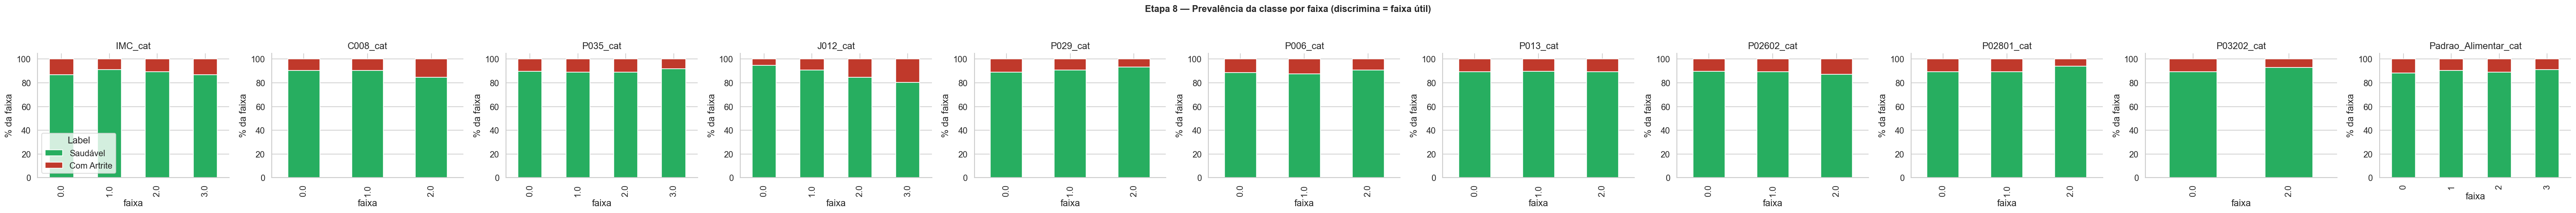

In [8]:
cats = [r['nova'] for r in log_disc if r['nova'] in df_disc.columns]
if cats:
    fig, axes = plt.subplots(1, len(cats), figsize=(4.6*len(cats), 4))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, cats):
        tab = (pd.crosstab(df_disc[col], y, normalize='index')*100).rename(
               columns={0:'Saudável',1:'Com Artrite'})
        tab.plot(kind='bar', stacked=True, ax=ax,
                 color=[COR_SAUDAVEL, COR_ARTRITE], legend=(ax is axes[0]))
        ax.set_title(col); ax.set_xlabel('faixa'); ax.set_ylabel('% da faixa')
    fig.suptitle('Etapa 8 — Prevalência da classe por faixa (discrimina = faixa útil)',
                 y=1.04, fontsize=13, weight='bold')
    plt.tight_layout(); salvar_fig(DIR_FIGURAS, 'etapa8_prevalencia_por_faixa.png'); plt.show()
else:
    print('  ⚠️ Nenhuma faixa criada para avaliar.')

## 9 · Seleção de atributos — entropia + correlação

**Aqui (e só aqui) a entropia entra** — igual aos artigos (etapa "Remoção de Atributos por
Entropia/Correlação"). Entropia muito baixa ⇒ atributo quase constante (candidato a remoção);
correlação muito alta com `Label` ⇒ alerta de **variável-consequência** (slide
*Consequência×Causalidade*), diretamente ligado ao **data leakage do Desenho 2** (as `Q*`).

> Só **sinalizamos**; a remoção é decisão documentada (como os artigos: "não foi possível
> eliminar pois a entropia estava próxima entre os atributos").

In [9]:
def entropia_shannon(serie):
    p = serie.value_counts(normalize=True, dropna=True); p = p[p > 0]
    return float(-(p*np.log2(p)).sum())

feat_final = cats + ja_categoricas
diag = []
for c in feat_final:
    if c not in df_disc.columns: continue
    col = pd.to_numeric(df_disc[c], errors='coerce')
    corr = np.corrcoef(col.fillna(col.median()), y)[0,1] if col.nunique() > 1 else 0.0
    diag.append({'feature':c, 'entropia':round(entropia_shannon(df_disc[c]),3),
                 'corr_abs_Label':round(abs(corr),3), 'n_unicos':int(df_disc[c].nunique())})

tab_sel = pd.DataFrame(diag).sort_values('entropia')
LIMIAR_ENTROPIA, LIMIAR_CORR = CFG['pipeline']['limiar_entropia'], CFG['pipeline']['limiar_corr']  # config.toml
tab_sel['sinal'] = np.where(tab_sel['entropia'] < LIMIAR_ENTROPIA, 'baixa_entropia',
                   np.where(tab_sel['corr_abs_Label'] > LIMIAR_CORR, 'alta_corr_alvo', 'ok'))
salvar_tab(DIR_TABELAS, tab_sel.set_index('feature'), 'etapa9_selecao_entropia_correlacao.csv')
print(tab_sel['sinal'].value_counts(), '\n')
print('  ⚠️ Revisar (NÃO remover automaticamente):',
      tab_sel.loc[tab_sel.sinal != 'ok','feature'].tolist())
tab_sel.head(15)

  ✅ Tabela → ../data/results/discretizacao/tabelas/etapa9_selecao_entropia_correlacao.csv
sinal
ok                43
baixa_entropia     9
Name: count, dtype: int64 

  ⚠️ Revisar (NÃO remover automaticamente): ['J01002_Outro serviço', 'J01002_Atendimento domiciliar', 'G060_Sim', 'J01101_Nunca foi ao médico', 'P02101_Diet/Light/Zero', 'G062_Não', 'P02601_Muito alto', 'P02101_Normal', 'P02102_Diet/Light/Zero']


,feature,entropia,corr_abs_Label,n_unicos,sinal
21,J01002_Outro serviço,0.020,0.001,2,baixa_entropia
18,J01002_Atendimento domiciliar,0.027,0.009,2,baixa_entropia
28,G060_Sim,0.048,0.022,2,baixa_entropia
17,J01101_Nunca foi ao médico,0.053,0.026,2,baixa_entropia
44,P02101_Diet/Light/Zero,0.056,0.001,2,baixa_entropia
29,G062_Não,0.060,0.012,2,baixa_entropia
36,P02601_Muito alto,0.069,0.001,2,baixa_entropia
45,P02101_Normal,0.079,0.006,2,baixa_entropia
46,P02102_Diet/Light/Zero,0.087,0.010,2,baixa_entropia
20,J01002_Farmácia,0.113,0.009,2,ok


## 10 · Codificação ordinal final e limpeza

Garante cada `_cat` como inteiro `0..k` e **remove as contínuas originais** já discretizadas
(evita "duplicações e redundâncias" do slide). Dummies OHE e ordinais herdadas do NB03 seguem
intactas.

In [10]:
df_out = df_disc.copy()
originais = [c for c in (list(FAIXAS)+list(FAIXAS_QUANTIS))
             if f'{c}_cat' in df_out.columns and c in df_out.columns]
# escores consumidos pelo plano cartesiano + razão aposentada
consumidas_plano = [PLANO_ALIMENTAR['eixo_infl'], PLANO_ALIMENTAR['eixo_saud']] + PLANO_ALIMENTAR['remover_extra']
removidas = [c for c in (originais + consumidas_plano + COLUNAS_REDUNDANTES) if c in df_out.columns]
df_out.drop(columns=removidas, inplace=True)
for c in [col for col in df_out.columns if col.endswith('_cat')]:
    df_out[c] = df_out[c].astype('Int64')
print(f'  Removidas (discretizadas/consumidas): {removidas}')
print(f'  Dataset após discretização: {df_out.shape[0]:,} × {df_out.shape[1]}')
df_out.head()

  Removidas (discretizadas/consumidas): ['IMC', 'C008', 'P035', 'J012', 'P029', 'P006', 'P013', 'P02602', 'P02801', 'P03202', 'Escore_Inflamatorio', 'Escore_Saudavel', 'P00104', 'P00404', 'P01101', 'P02501', 'P02002', 'P02001', 'P018', 'P00901', 'P015', 'P023', 'P01601']
  Dataset após discretização: 4,826 × 59


,VDF004,VDD004A,N001,N010,N011,G081,Q05901,C006_Mulher,P034_Sim,I00102_Sim,...,C008_cat,P035_cat,J012_cat,P029_cat,P006_cat,P013_cat,P02602_cat,P02801_cat,P03202_cat,Padrao_Alimentar_cat
0,2.0,4.0,1.0,3.0,0.0,0.0,0.0,1,1,1,...,0,1,1,0,1,1,0,0,0,2
1,4.0,1.0,0.0,0.0,0.0,0.0,5.0,0,0,0,...,0,0,0,1,0,1,2,1,0,3
2,3.0,1.0,3.0,3.0,1.0,0.0,0.0,0,1,0,...,0,3,1,0,2,1,0,0,0,0
3,3.0,1.0,1.0,3.0,2.0,1.0,3.0,1,1,0,...,0,3,0,0,2,1,0,0,0,3
4,2.0,0.0,2.0,0.0,0.0,0.0,5.0,0,0,0,...,0,0,1,1,2,1,0,1,0,3


## 11 · Exportação e relatório (desenho ativo)

Mesmo padrão do NB03: CSV pronto para o NB05 + JSON auditável (cada corte, fonte, método e os
sinais da seleção por entropia). Esta célula é só **inspeção** do desenho ativo (`DESENHO`); a **gravação oficial dos dois**
desenhos é feita pela Seção 12.

In [11]:
df_final = df_out.copy(); df_final['Label'] = y.values
caminho_dataset = DIR_RESULTADOS + 'dataset_discretizado.csv'
# Parte A é só INSPEÇÃO (passo a passo de UM desenho); a escrita oficial dos DOIS
# desenhos é feita pela Parte B (Seção 12) — evita processar/gravar o ativo duas vezes.
print(f'  ℹ️  Parte A (inspeção): df_final = {df_final.shape[0]:,} × {df_final.shape[1]} — arquivos gravados pela Parte B.')

relatorio = {
    'projeto':'Artrite e Reumatismo em Idosos Brasileiros — PNS 2019',
    'pesquisador':'Pedro Dias Soares', 'orientador':'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'notebook':'04_discretizacao', 'desenho':DESENHO, 'rotulo':cfg['rotulo'],
    'metodo':('Discretização não-supervisionada univariada por faixas de domínio (OMS/Guia BR); '
              'escores alimentares combinados em plano cartesiano (mediana → 4 quadrantes). Entropia+correlação só p/ seleção.'),
    'parametros':{'RANDOM_STATE':RANDOM_STATE,'LIMIAR_ENTROPIA':LIMIAR_ENTROPIA,'LIMIAR_CORR':LIMIAR_CORR},
    'rastreabilidade':{
        'entrada':caminho_in, 'faixas_aplicadas':log_disc, 'continuas_removidas':removidas,
        'selecao_atributos':tab_sel.to_dict('records'),
        'dataset_final':{'n_registros':int(df_final.shape[0]),'n_features':int(df_final.shape[1]-1),
            'distribuicao_label':{str(k):int(v) for k,v in y.value_counts().items()},
            'arquivo':caminho_dataset}}}
# (o relatório JSON também é gravado só pela Parte B, Seção 12 — Parte A não escreve em disco)

  ℹ️  Parte A (inspeção): df_final = 4,826 × 60 — arquivos gravados pela Parte B.


## 12 · Processar **os dois desenhos** de uma vez

A Parte A acima percorreu **um** desenho com gráficos, para inspeção. Esta seção reúne a mesma
lógica numa função `discretizar_desenho(...)` e roda **ambos** (`puro` e `comorbidades`),
gravando os dois `dataset_discretizado.csv` e os dois `relatorio_discretizacao.json`.

A função reaproveita os **mesmos** `FAIXAS`/`FAIXAS_QUANTIS` (são clínicos, valem para os dois
desenhos) e detecta sozinha quais colunas existem em cada um — por isso atende tanto o 03 (sem
`Q*`) quanto o 03b (com `Q*`). É o que torna o NB04 "capaz de receber os resultados de ambos os
NB03".

In [12]:
def discretizar_desenho(nome, cfg, FAIXAS, FAIXAS_QUANTIS,
                         LIMIAR_ENTROPIA=0.10, LIMIAR_CORR=0.60, plot=False):
    """Pipeline completo de discretização para UM desenho. Retorna (df_final, relatorio)."""
    figs, tabs = preparar_dirs(cfg['saida'])
    assert os.path.exists(cfg['entrada']), f"Entrada ausente: {cfg['entrada']} (rode o NB03/03b)."
    df_ = pd.read_csv(cfg['entrada'])
    y_  = df_['Label'].astype(int)
    Xd  = df_.drop(columns=['Label']).copy()

    # --- discretização por domínio + quantis ---
    log = []
    for col, spec in FAIXAS.items():
        if col not in Xd.columns: continue
        Xd[f'{col}_cat'] = pd.cut(pd.to_numeric(Xd[col], errors='coerce'),
            bins=spec['bins'], labels=spec['labels'], include_lowest=True,
            right=spec['right']).astype('float')
        log.append({'variavel':col,'nova':f'{col}_cat','metodo':'dominio',
                    'n_faixas':len(spec['labels']),'fonte':spec['fonte'],
                    'distribuicao':Xd[f'{col}_cat'].value_counts(dropna=False).sort_index().to_dict()})
    for col, spec in FAIXAS_QUANTIS.items():
        if col not in Xd.columns: continue
        try:
            Xd[f'{col}_cat'] = pd.qcut(pd.to_numeric(Xd[col], errors='coerce'),
                q=spec['q'], labels=spec['labels'], duplicates='drop').astype('float')
            log.append({'variavel':col,'nova':f'{col}_cat','metodo':'quantis',
                        'n_faixas':spec['q'],'fonte':spec['fonte'],
                        'distribuicao':Xd[f'{col}_cat'].value_counts(dropna=False).sort_index().to_dict()})
        except ValueError:
            pass

    # --- plano cartesiano dos padrões alimentares ---
    pa = PLANO_ALIMENTAR
    if pa['eixo_infl'] in Xd.columns and pa['eixo_saud'] in Xd.columns:
        Xd[pa['nova']] = discretizar_plano_alimentar(Xd[pa['eixo_infl']], Xd[pa['eixo_saud']])
        log.append({'variavel':f"{pa['eixo_infl']} x {pa['eixo_saud']}", 'nova':pa['nova'],
                    'metodo':'plano_cartesiano', 'n_faixas':4, 'fonte':pa['fonte'],
                    'distribuicao':dist_serializavel(Xd[pa['nova']].value_counts(dropna=False).sort_index().to_dict())})

    # --- seleção entropia + correlação (apenas sinaliza) ---
    cats_ = [r['nova'] for r in log if r['nova'] in Xd.columns]
    ja_cat = [c for c in Xd.columns
              if not (pd.api.types.is_numeric_dtype(Xd[c]) and Xd[c].nunique(dropna=True) > 2)]
    diag = []
    for c in sorted(set(cats_ + ja_cat)):  # sorted: ordem determinística (evita diff espúrio em empates de entropia)
        col = pd.to_numeric(Xd[c], errors='coerce')
        ent = entropia_shannon(Xd[c])
        corr = np.corrcoef(col.fillna(col.median()), y_)[0,1] if col.nunique() > 1 else 0.0
        diag.append({'feature':c,'entropia':round(ent,3),'corr_abs_Label':round(abs(corr),3)})
    tab_sel_ = pd.DataFrame(diag).sort_values('entropia')
    tab_sel_['sinal'] = np.where(tab_sel_['entropia'] < LIMIAR_ENTROPIA, 'baixa_entropia',
                        np.where(tab_sel_['corr_abs_Label'] > LIMIAR_CORR, 'alta_corr_alvo', 'ok'))
    salvar_tab(tabs, tab_sel_.set_index('feature'), 'etapa9_selecao_entropia_correlacao.csv')

    # --- limpeza: remove contínuas já discretizadas, _cat como Int64 ---
    originais_ = [c for c in (list(FAIXAS)+list(FAIXAS_QUANTIS))
                  if f'{c}_cat' in Xd.columns and c in Xd.columns]
    consumidas_ = [PLANO_ALIMENTAR['eixo_infl'], PLANO_ALIMENTAR['eixo_saud']] + PLANO_ALIMENTAR['remover_extra']
    removidas_ = [c for c in (originais_ + consumidas_ + COLUNAS_REDUNDANTES) if c in Xd.columns]
    Xd.drop(columns=removidas_, inplace=True)
    for c in [col for col in Xd.columns if col.endswith('_cat')]:
        Xd[c] = Xd[c].astype('Int64')

    # --- exportação ---
    out = Xd.copy(); out['Label'] = y_.values
    csv_path = cfg['saida'] + 'dataset_discretizado.csv'
    out.to_csv(csv_path, index=False, encoding='utf-8-sig')
    rel = {
        'projeto':'Artrite e Reumatismo em Idosos Brasileiros — PNS 2019',
        'pesquisador':'Pedro Dias Soares','orientador':'Prof. Dr. Luis Enrique Zárate — PUC Minas',
        'notebook':'04_discretizacao','desenho':nome,'rotulo':cfg['rotulo'],
        'metodo':('Discretização não-supervisionada univariada por faixas de domínio (OMS/Guia BR); '
                  'escores alimentares combinados em plano cartesiano (mediana → 4 quadrantes). Entropia+correlação só p/ seleção.'),
        'parametros':{'RANDOM_STATE':RANDOM_STATE,'LIMIAR_ENTROPIA':LIMIAR_ENTROPIA,'LIMIAR_CORR':LIMIAR_CORR},
        'rastreabilidade':{
            'entrada':cfg['entrada'],'faixas_aplicadas':log,'continuas_removidas':removidas_,
            'selecao_atributos':tab_sel_.to_dict('records'),
            'dataset_final':{'n_registros':int(out.shape[0]),'n_features':int(out.shape[1]-1),
                'distribuicao_label':{str(k):int(v) for k,v in y_.value_counts().items()},
                'arquivo':csv_path}}}
    with open(cfg['saida']+'relatorio_discretizacao.json','w',encoding='utf-8') as f:
        json.dump(rel, f, ensure_ascii=False, indent=2)
    print(f'  ✅ [{nome}] {cfg["rotulo"]}: {out.shape[0]:,} × {out.shape[1]} → {csv_path}')
    return out, rel

# --- roda os DOIS desenhos ---
resultados = {}
for nome, c in CONFIG_DESENHOS.items():
    print(f'\n── Processando {nome} ──────────────────────────────')
    resultados[nome] = discretizar_desenho(nome, c, FAIXAS, FAIXAS_QUANTIS,
                                            LIMIAR_ENTROPIA, LIMIAR_CORR)
print('\n✅ Ambos os desenhos discretizados.')


── Processando puro ──────────────────────────────


  ✅ Tabela → ../data/results/discretizacao/tabelas/etapa9_selecao_entropia_correlacao.csv

  ✅ [puro] Desenho 1 — Artrite pura: 4,826 × 60 → ../data/results/discretizacao/dataset_discretizado.csv

── Processando comorbidades ──────────────────────────────


  ✅ Tabela → ../data/results/discretizacao_comorbidades/tabelas/etapa9_selecao_entropia_correlacao.csv
  ✅ [comorbidades] Desenho 2 — Artrite + comorbidades: 8,357 × 57 → ../data/results/discretizacao_comorbidades/dataset_discretizado.csv

✅ Ambos os desenhos discretizados.


## ✅ Sumário Final

In [13]:
print('=' * 80)
print('  ✅  NOTEBOOK 04 — DISCRETIZAÇÃO CONCLUÍDA (ambos os desenhos)')
print('=' * 80)
print(f'  Faixas por domínio : {list(FAIXAS)}')
print(f'  Faixas por quantis : {list(FAIXAS_QUANTIS)}')
for nome, (out, rel) in resultados.items():
    info = rel['rastreabilidade']['dataset_final']
    print(f'  [{nome:13s}] {out.shape[0]:,} × {out.shape[1]} | alvo={info["distribuicao_label"]}'
          f' → {info["arquivo"]}')
print('  Próximo passo       : NB05 — Exportação das bases; depois NB06 — Modelagem (Reg. Logística, Árvore, Random Forest; RUS+CV)')
print('  Anti-leakage: comorbidades-filtro removidas no NB03b (só Q084 permanece no D2).')
print('=' * 80)

  ✅  NOTEBOOK 04 — DISCRETIZAÇÃO CONCLUÍDA (ambos os desenhos)
  Faixas por domínio : ['IMC', 'C008', 'P035', 'J012', 'P029', 'P006', 'P013', 'P02602', 'P02801', 'P03202']
  Faixas por quantis : []
  [puro         ] 4,826 × 60 | alvo={'0': 4332, '1': 494} → ../data/results/discretizacao/dataset_discretizado.csv
  [comorbidades ] 8,357 × 57 | alvo={'0': 4332, '1': 4025} → ../data/results/discretizacao_comorbidades/dataset_discretizado.csv
  Próximo passo       : NB05 — Exportação das bases; depois NB06 — Modelagem (Reg. Logística, Árvore, Random Forest; RUS+CV)
  Anti-leakage: comorbidades-filtro removidas no NB03b (só Q084 permanece no D2).
